In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [2]:
columnas = [
    'ID', 'Diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

df = pd.read_csv("wdbc.data", header=None, names=columnas)

print(f"Dataset cargado: {df.shape[0]} registros y {df.shape[1]} columnas")
df.head()

Dataset cargado: 569 registros y 32 columnas


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Exploración de los datos

Se realiza una exploración inicial del conjunto de datos para conocer su estructura, identificar valores nulos o registros duplicados y analizar la distribución de la variable objetivo.

In [3]:
print("=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)

df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum())

print(f"\nRegistros duplicados: {df.duplicated().sum()}")

print("\nDistribución del diagnóstico:")
print(df['Diagnosis'].value_counts())

print("\nDistribución porcentual:")
print(df['Diagnosis'].value_counts(normalize=True).mul(100).round(2))

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  pe

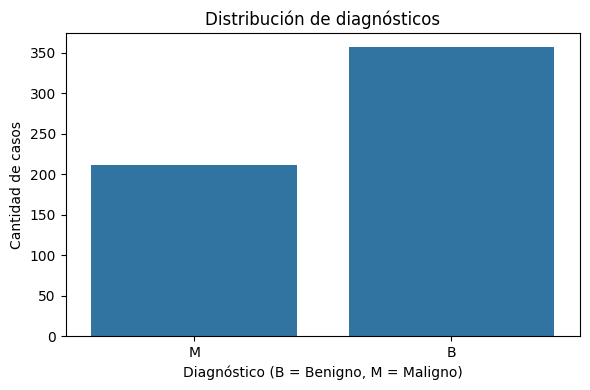

In [4]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Diagnosis')

plt.title('Distribución de diagnósticos')
plt.xlabel('Diagnóstico (B = Benigno, M = Maligno)')
plt.ylabel('Cantidad de casos')

plt.tight_layout()
plt.show()


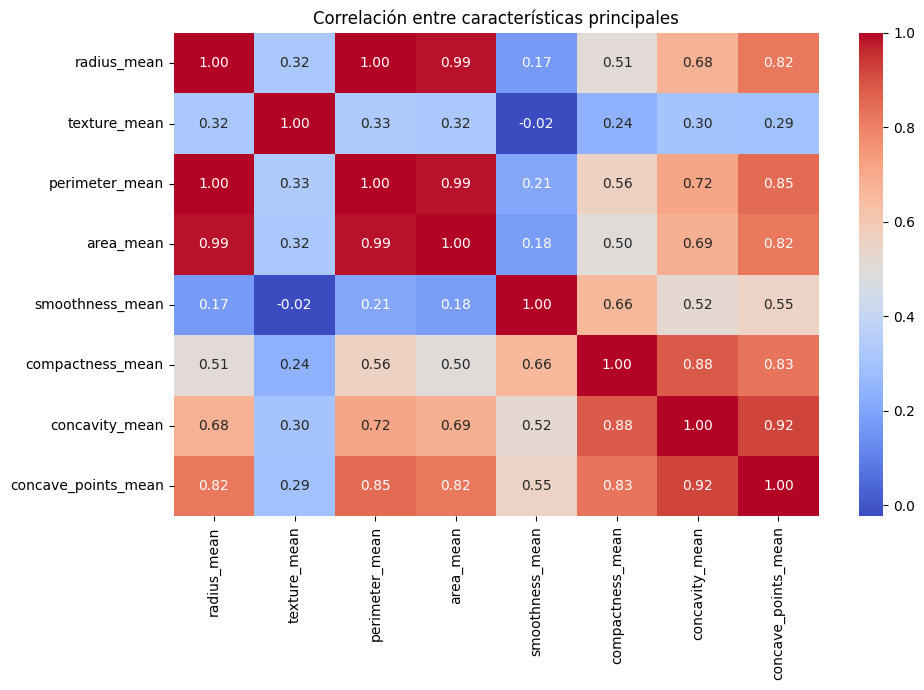

In [5]:
columnas_correlacion = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave_points_mean'
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[columnas_correlacion].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlación entre características principales')
plt.tight_layout()
plt.show()

## 3. Preparación de los datos

Se elimina la columna ID, ya que funciona únicamente como identificador y no aporta información útil para la clasificación. Posteriormente, se separan las características de entrada y la variable objetivo, y se divide el conjunto de datos en 80% para entrenamiento y 20% para prueba mediante un muestreo estratificado.

In [6]:
from sklearn.model_selection import train_test_split

# Características utilizadas para realizar la predicción
X = df.drop(columns=['ID', 'Diagnosis'])

# Variable que queremos predecir
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Características utilizadas: {X.shape[1]}")
print(f"Datos de entrenamiento: {X_train.shape[0]}")
print(f"Datos de prueba: {X_test.shape[0]}")

print("\nDistribución en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución en prueba:")
print(y_test.value_counts())

Características utilizadas: 30
Datos de entrenamiento: 455
Datos de prueba: 114

Distribución en entrenamiento:
Diagnosis
B    285
M    170
Name: count, dtype: int64

Distribución en prueba:
Diagnosis
B    72
M    42
Name: count, dtype: int64


## 4. Entrenamiento de modelos

Se entrenan tres algoritmos de clasificación: Regresión Logística, Árbol de Decisión y Random Forest. Para cada modelo se utiliza un Pipeline y validación cruzada de 5 particiones, permitiendo comparar su rendimiento antes de seleccionar el mejor modelo.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=2000),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

resultados = {}

for nombre, modelo in modelos.items():

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', modelo)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    resultados[nombre] = scores.mean()

    print(f"{nombre}: {scores.mean():.4f}")


Regresión Logística: 0.9714
Árbol de Decisión: 0.9319
Random Forest: 0.9582


## 5. Evaluación del modelo

La Regresión Logística obtuvo el mejor rendimiento durante la validación cruzada, con una exactitud promedio de 97.14%. Por ello, se selecciona como modelo final y se evalúa utilizando el conjunto de prueba.

In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Crear el modelo final
modelo_final = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=2000))
])

# Entrenar utilizando únicamente los datos de entrenamiento
modelo_final.fit(X_train, y_train)

# Realizar predicciones sobre datos que el modelo no ha visto
y_pred = modelo_final.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy en prueba: {accuracy:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy en prueba: 0.9649

Reporte de clasificación:
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



<Figure size 600x500 with 0 Axes>

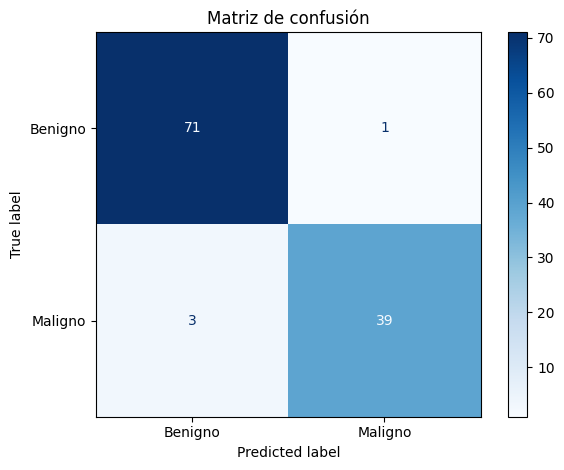

In [10]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Benigno', 'Maligno'],
    cmap='Blues'
)

plt.title('Matriz de confusión')
plt.tight_layout()
plt.show()

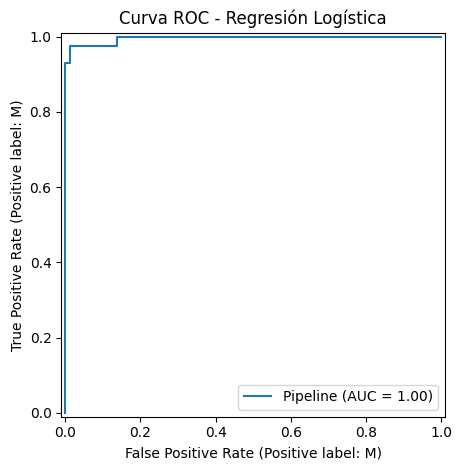

In [11]:
RocCurveDisplay.from_estimator(
    modelo_final,
    X_test,
    y_test,
    pos_label='M'
)

plt.title('Curva ROC - Regresión Logística')
plt.tight_layout()
plt.show()

## 6. Despliegue del modelo

El modelo final se serializa mediante Joblib para permitir su almacenamiento y reutilización sin necesidad de volver a entrenarlo. Además, se implementa una función de inferencia que permite realizar predicciones utilizando nuevos datos.

In [12]:
import joblib

joblib.dump(modelo_final, "modelo_cancer_mama.pkl")

print("Modelo guardado correctamente como 'modelo_cancer_mama.pkl'")

Modelo guardado correctamente como 'modelo_cancer_mama.pkl'


In [13]:
modelo_cargado = joblib.load("modelo_cancer_mama.pkl")

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [15]:
def predecir_diagnostico(datos_paciente):
    datos = pd.DataFrame(
        [datos_paciente],
        columns=X.columns
    )

    prediccion = modelo_cargado.predict(datos)[0]

    if prediccion == 'M':
        return "Maligno"
    else:
        return "Benigno"


In [16]:
ejemplo = X_test.iloc[0].values

resultado = predecir_diagnostico(ejemplo)

print("Predicción:", resultado)
print("Diagnóstico real:", "Maligno" if y_test.iloc[0] == 'M' else "Benigno")

Predicción: Benigno
Diagnóstico real: Benigno
